# Notebook 8 | Probability Tree

In [1]:
from foundations_of_probability_and_statistics.cars.car_distribution import create_joint_car_distribution

import matplotlib.pyplot as plt
import pandas as pd

# show all rows of data frames and series per default
pd.set_option("display.max_rows", None)

## The tree as nested product rule

The tree draws the factorization $p(B = b, H = h, C = c) = p(b) \, p(h \mid b) \, p(c \mid b)$ level by level:
brand edges from the root, horsepower edges per brand, color edges per brand. A root-to-leaf path product is
the joint probability of that leaf, and summing leaves marginalizes, exactly as in notebooks 2 and 7.

## Derivation

1. Root splits into brands with edge weights $p(b)$: $0.5$, $0.3$, $0.2$.
2. Each brand node splits into colors with edge weights $p(c \mid b)$, e.g. VW to gray with $0.5$.
3. A path product gives the leaf: $p(\text{VW} \to \text{gray}) = 0.5 \cdot 0.5 = 0.25$.
4. Summing the leaves of one color gives the marginal, e.g. $p(\text{red}) = 0.2 \cdot 0.6 = 0.12$.

## Worked example (by hand)

Path product down the VW branch:

$$p(\text{VW} \to \text{gray}) = 0.5 \cdot 0.5 = 0.25.$$

Leaf sum for red, reached only through Ferrari:

$$p(\text{red}) = 0.2 \cdot 0.6 = 0.12.$$

In [2]:
import math

joint = create_joint_car_distribution()

# path product: p(VW -> gray) = p(VW) p(gray | VW)
assert math.isclose(0.5 * 0.5, 0.25)
assert math.isclose(joint.xs("VW", level="brand").xs("gray", level="color").sum(), 0.25)

# leaf sum: p(red) = p(Ferrari) p(red | Ferrari)
assert math.isclose(0.2 * 0.6, 0.12)
assert math.isclose(joint.xs("red", level="color").sum(), 0.12)
joint.xs("red", level="color").sum()

np.float64(0.12)

## Generalization

The single-use tree figure below draws the brand-to-color layer: edge widths scale with the path probability
$p(b) \, p(c \mid b)$, so the dominant gray-VW and black-Porsche paths stand out while the red-Ferrari leaf
carries the full $0.12$ of red.

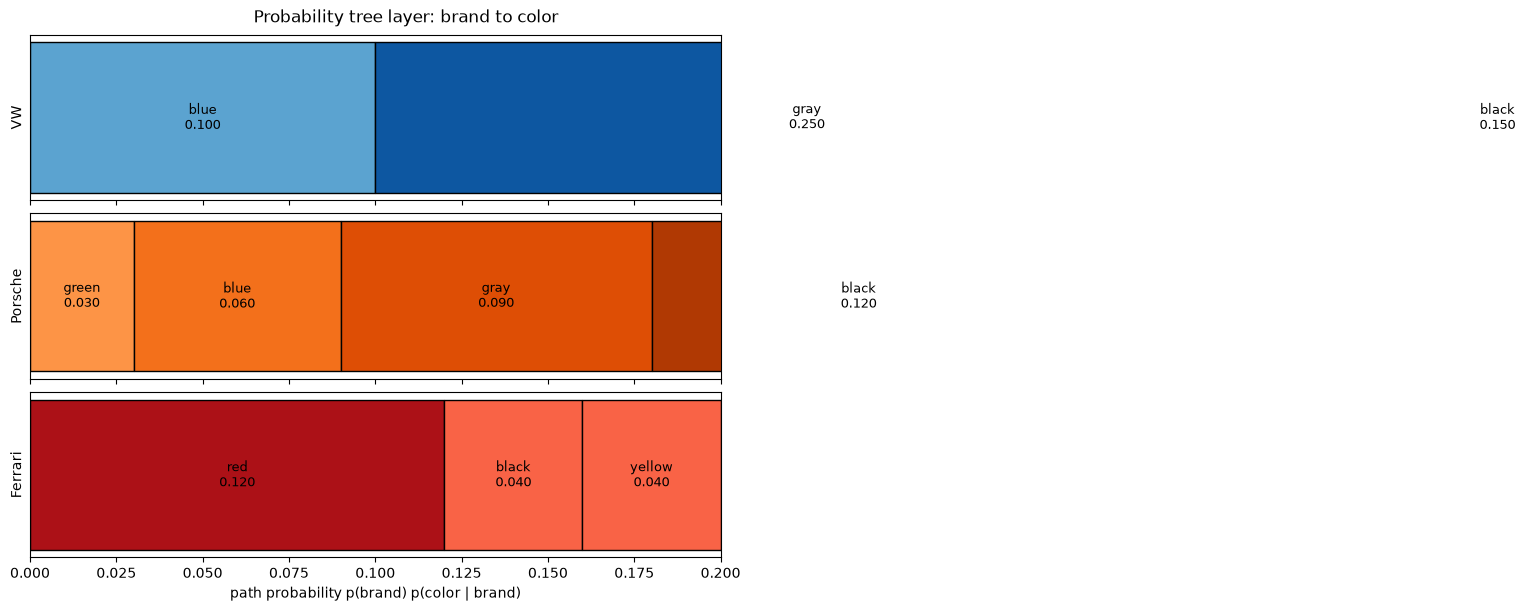

/Users/sven/gh/foundations-of-probability-and-statistics/.venv/lib/python3.14/site-packages/IPython/core/events.py:101: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/Users/sven/gh/foundations-of-probability-and-statistics/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


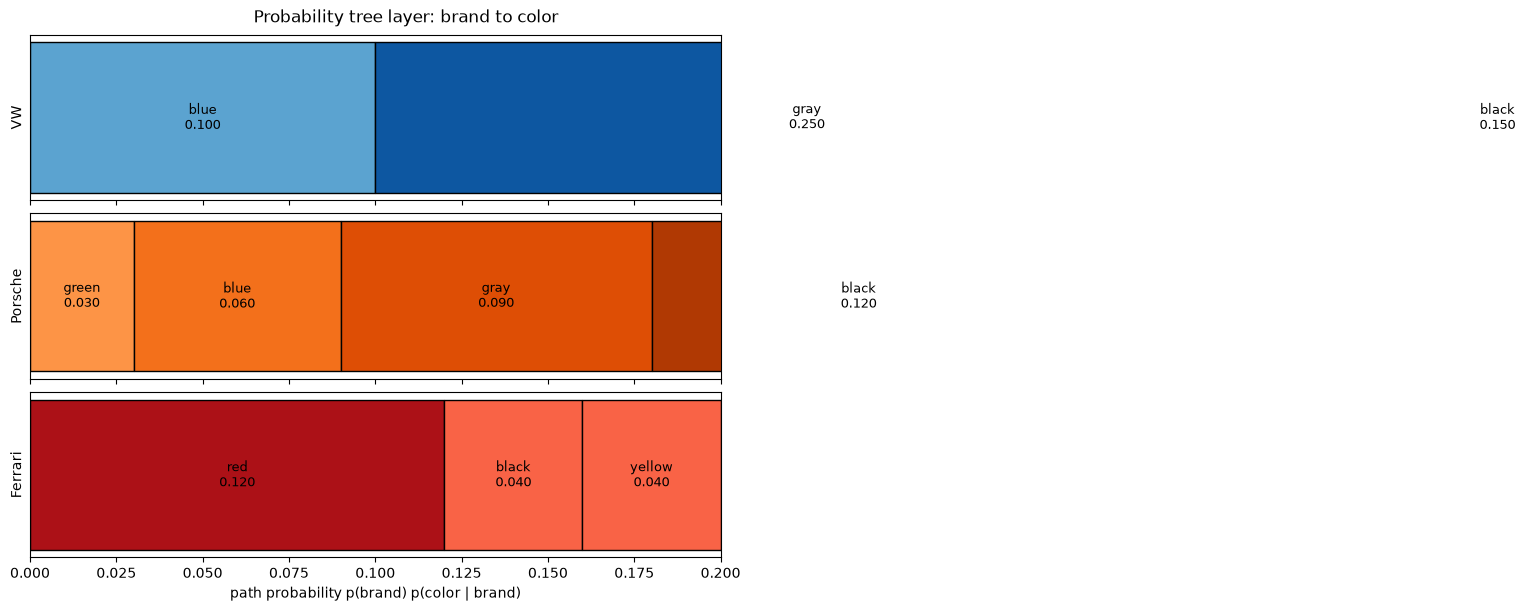

In [3]:
import matplotlib

brand_colors = {"VW": matplotlib.colormaps["Blues"], "Porsche": matplotlib.colormaps["Oranges"], "Ferrari": matplotlib.colormaps["Reds"]}
brand_priors = {"VW": 0.5, "Porsche": 0.3, "Ferrari": 0.2}
brand_color_probs = {
    "VW": {"blue": 0.2, "gray": 0.5, "black": 0.3},
    "Porsche": {"green": 0.1, "blue": 0.2, "gray": 0.3, "black": 0.4},
    "Ferrari": {"red": 0.6, "black": 0.2, "yellow": 0.2},
}

# one row per brand, one path segment per color with width scaled by p(b) p(c | b)
figure, axes = plt.subplots(3, 1, figsize=(8.0, 6.0), dpi=100, layout="constrained", sharex=True)
for ax, brand in zip(axes, ["VW", "Porsche", "Ferrari"], strict=True):
    colors = list(brand_color_probs[brand])
    widths = [brand_priors[brand] * brand_color_probs[brand][color] for color in colors]
    # shade tiles from lighter to darker with the conditional probability
    fills = [brand_colors[brand](0.35 + 0.5 * prob / max(brand_color_probs[brand].values())) for prob in [brand_color_probs[brand][c] for c in colors]]
    left = 0.0
    for color, width, fill in zip(colors, widths, fills, strict=True):
        ax.barh(0, width, left=left, color=fill, edgecolor="black")
        ax.text(left + width / 2, 0, f"{color}\n{width:.3f}", ha="center", va="center", fontsize=9)
        left += width
    ax.set_xlim(0.0, brand_priors[brand])
    ax.set_yticks([])
    ax.set_ylabel(brand)
axes[-1].set_xlabel("path probability p(brand) p(color | brand)")
figure.suptitle("Probability tree layer: brand to color")
figure

## References

- Blitzstein, J. K., Hwang, J. (2019): "Introduction to Probability", 2nd ed., Chapman & Hall/CRC, chapter "Conditional Probability", https://www.routledge.com/Introduction-to-Probability-Second-Edition/Blitzstein-Hwang/p/book/9781138369917 (free PDF: https://probabilitybook.net/).
- Wasserman, L. (2004): "All of Statistics: A Concise Course in Statistical Inference", Springer Texts in Statistics, chapter "Probability", https://doi.org/10.1007/978-0-387-21736-9.
- scipy.stats.rv_discrete, https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html.